<a href="https://colab.research.google.com/github/clararmbastos-310/MVP-ML-ANALYTICS-CLARA-BASTOS/blob/main/Clara_Bastos_MVP_ML_Analytics_20261.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics

**Nome:** Clara Bastos

**Matrícula:** 17780524795

**Data:** 05/07/2026  

**Dataset:** [Adult Census Income](https://archive.ics.uci.edu/dataset/2/adult)

**Tipo de problema:** Classificação


# 1. Definição do problema


## 1.1 Descrição do problema

Este trabalho utiliza o dataset Adult Census Income, que reúne informações demográficas e profissionais de indivíduos coletadas pelo censo dos Estados Unidos. O objetivo é **classificar** os indivíduos de acordo com sua faixa de renda (acima ou abaixo de 50K) e investigar quais características influenciam essa classificação. A análise dá foco à comparação entre homens e mulheres, buscando entender se os fatores se associam de forma diferente à renda dos dois grupos. Dessa forma, trata-se de uma análise relevante tanto para pesquisadores que estudam desigualdade de renda e equidade de gênero quanto para gestores de RH e formuladores de políticas públicas interessados em identificar disparidades e propor ações baseadas em evidências.

## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a faixa de renda (income) de indivíduos a partir de suas características demográficas e profissionais, comparando uma abordagem baseline com modelos candidatos e analisando, em particular, como essas características se relacionam de forma diferente entre homens e mulheres.

## 1.3 Tipo de problema

**Tipo escolhido:** Classificação

**Justificativa:** Trata-se de um problema de classificação, já que a variável-alvo, income, é categórica e possui duas classes (renda anual ≤50K ou >50K).

Esse problema pode ser tratado com Machine Learning, uma vez que a relação entre características demográficas e profissionais e a faixa de renda é complexa e não pode ser descrita por regras simples. Como o dataset já possui a variável de renda rotulada, é possível aplicar aprendizado supervisionado para identificar padrões e realizar previsões para novos casos.


## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. O gênero está associado à faixa de renda do indivíduo?
2. O impacto do nível educacional sobre a probabilidade de renda alta é diferente entre homens e mulheres?
3. A carga horária semanal de trabalho influencia a renda de forma diferente para homens e mulheres?

**Critérios de sucesso:**
- Métrica principal: F1-score. Escolhida devido ao desbalancemaneto entre as classes. O dataset aprenseta um menor concetração de dados com presença da classe de renda superior (>50K).
- Resultado mínimo esperado: Superar o DummyClassifier (que sempre prevê a classe majoritária <=50K) em pelo menos 10 pontos percentuais de F1-score na classe minoritária (>50K).
- Restrição prática: Manter a interpretabilidade do modelo, uma vez que o objetivo do trabalho é compreender quais variáveis mais influenciam a renda dos indivíduos. Por isso, serão priorizados modelos que permitam a análise de importância de features, como Regressão Logística, Random Forest e Gradient Boosting.

# 2. Importação da Bibliotecas Necessárias

In [363]:
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)
from scipy.stats import randint
from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


def evaluate_classification(y_true, y_pred, proba=None):
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted")
    }
    try:
        if proba is not None and proba.shape[1] == 2:
            results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan
    return results


def show_results_table(results_dict):
    return pd.DataFrame(results_dict).T

Python: 3.12.13
Seed: 42


# 3. Seleção e carga dos dados



##3.1 Fonte de Dados



###3.1.1 Descrição do Dataset

O dataset [Adult Census Income](https://archive.ics.uci.edu/dataset/2/adult) contém dados demográficos e socioeconômicos de indivíduos coletados a partir do Censo dos Estados Unidos de 1994. Seu principal uso está na classificação dos indivíduos de acordo com a faixa de renda anual, separando-os entre aqueles que recebem até 50.000 por ano e aqueles que recebem acima desse valor. A base inclui variáveis como idade, escolaridade, ocupação, estado civil, raça, sexo, horas trabalhadas e país de origem.

Por ser um dataset é público, que não há identificação direta dos indivíduos, pode ser utilizado para fins acadêmicos, sem problemas relacionados à ética, privacidade, confidencialidade ou licença.

O dataset foi escolhido por apresentar a variável *sex* juntamente com outras características socioeconômicas relevantes, o que possibilita a investigação de desigualdades de renda entre esses grupos, atendendo ao objetivo do trabalho, que é entender as diferenças entre homens e mulheres no mercado de trabalho.

###3.1.2 Restrições e condições consideradas

Foram considerados apenas indivíduos cujo país de origem é os Estados Unidos, com o objetivo de tornar a análise mais consistente em relação ao contexto socioeconômico. Além disso, algumas variáveis foram desconsideradas por não serem diretamente relevantes para os objetivos da análise, como a variável fnlwgt, que representa um peso amostral, e a variável education-num, por ser redundante em relação à variável categórica education. Essas seleções e ajustes serão implementados nas etapas seguintes do notebook, durante o carregamento e preparação dos dados.

## 3.2 Carga dos dados



In [364]:
#importando url com dados para um dataframe
url_dados = "https://raw.githubusercontent.com/clararmbastos-310/MVP-ML-ANALYTICS-CLARA-BASTOS/refs/heads/main/Base%20de%20Dados/adult.data"

#labels dos atributos do dataset
labels_atributos = ["age", "workclass", "fnlwgt", "education", "education-num",
                    "marital-status", "occupation", "relationship", "race", "sex",
                    "capital-gain", "capital-loss", "hours-per-week","native-country", "income"]

df = pd.read_csv(url_dados,names=labels_atributos)

#exibindo últimas linhas
df.tail()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [365]:
#Seleção de Dados:

#Selecionando apenas os dados em que o país de origem é Estados Unidos:
df_mvp = df[df['native-country'] == ' United-States']

#Excluindo as colunas fnlwgt e education-num por não serem relevantes para análise:
df_mvp = df_mvp.drop(columns=['fnlwgt', 'education-num'])

# Reorganizando index:
df_mvp = df_mvp.reset_index(drop=True)

#Exibindo últimas linhas:
df_mvp.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,37,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


## 3.3 Visão geral do dataset



O dataset original (df) possuía 32.561 instâncias e 15 atributos. Após a aplicação dos filtros e remoção de variáveis, o dataset resultante (df_mvp) passou a conter 29.170 instâncias e 13 atributos.

O dataset df_mvp possui 4 atributos numéricos e 9 categóricos, que serão descritos na seção de Dicionário de Dados.

In [366]:
#informações do dataset original
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

Formato do dataset: (32561, 15)

Tipos de dados:


,tipo
age,int64
workclass,object
fnlwgt,int64
education,object
education-num,int64
marital-status,object
occupation,object
relationship,object
race,object
sex,object


In [367]:
#Informações do dataset com a seleção de dados do mvp
print("Formato do dataset:", df_mvp.shape)
print("\nTipos de dados:")
display(df_mvp.dtypes.to_frame("tipo"))

Formato do dataset: (29170, 13)

Tipos de dados:


,tipo
age,int64
workclass,object
education,object
marital-status,object
occupation,object
relationship,object
race,object
sex,object
capital-gain,int64
capital-loss,int64


## 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| age | numérica |Representa a idade do indivíduo | Sim | Os valores variam de 17 a 90. Não existem valores nulos ou desconhecidos. |
| workclass | categórica | Representa a classe de trabalho do indivíduo. | Sim | Não existem valores nulos, porém existem valores desconhecidos representados por "?".|
| education | categórica | Representa o nível educacional do indivíduo. | Sim | Não existem valores nulos ou desconhecidos.|
| marital_status | categórica | Representa o estado civil do indivíduo. | Sim | Não existem valores nulos, porém existem valores desconhecidos representados por "?".|
| relationship | categórica | Representa a relação familiar indivíduo. | Sim | Não existem valores nulos e desconhecidos.|
| race | categórica | Representa a raça do indivíduo. | Sim | Não existem valores nulos e desconhecidos.|
| sex | categórica | Representa o sexo indivíduo. | Sim | Não existem valores nulos e desconhecidos.|
| capital-gain | numérico | Representa os ganhos de capital do indivíduo. | Sim | Os valores variam de 0 a 99999. Não existem valores nulos e desconhecidos.|
| capital-loss | numérico | Representa as perdas  de capital do indivíduo. | Sim | Os valores variam de 0 a 4356. Não existem valores nulos e desconhecidos.|
| hours-per-week | numérico | Representa as horas trabalhas por semana do indivíduo. | Sim | Os valores variam de 1 a 99. Não existem valores nulos e desconhecidos.|
| native-conty | categórico | Representa o país de origem do indivíduo. | Sim | Pela seleção de dados, foram considerados (filtrados) apenas o país de origem United-States. horas trabalhas por semana do indivíduo. Não existem valores nulos ou desconhecidos.
| income | alvo | Representa a faixa de renda do indivíduo | Alvo | Os valores são: <=50K (Até 50 mil); >50K (Acima de 50 mil). Não existem valores nulos ou desconhecidos.|
| fnlwgt | numérico | Representa o peso amostral atributo ao indivíduo considerando suas características. | Não | Não existem valores nulos ou desconhecidos.
| education_num | numérico | Representa a quantidade de anos de estudo. | Não | Os valores variam de 1 a 16. Não existem valores nulos ou desconhecidos.


# 4. Análise exploratória dos dados


##4.1 Resumo Estatísco - Estatísticas Descritivas

In [368]:
#Estatísticas descritivas básicas do dataset
df_mvp.describe()

,age,capital-gain,capital-loss,hours-per-week
count,29170.000000,29170.000000,29170.000000,29170.000000
mean,38.655674,1089.229928,88.510593,40.447755
std,13.722408,7381.898528,405.681709,12.417203
min,17.000000,0.000000,0.000000,1.000000
25%,28.000000,0.000000,0.000000,40.000000
50%,37.000000,0.000000,0.000000,40.000000
75%,48.000000,0.000000,0.000000,45.000000
max,90.000000,99999.000000,4356.000000,99.000000


In [369]:
#Analisando a moda dos atributos
for col in df_mvp.select_dtypes(include='int64').columns:
    print(f"\nColuna: {col}")
    print(df_mvp[col].mode())


Coluna: age
0    36
Name: age, dtype: int64

Coluna: capital-gain
0    0
Name: capital-gain, dtype: int64

Coluna: capital-loss
0    0
Name: capital-loss, dtype: int64

Coluna: hours-per-week
0    40
Name: hours-per-week, dtype: int64


Foram analisadas as estatísticas descritivas das variáveis numéricas por meio do método describe(), permitindo identificar medidas de tendência central, dispersão e possíveis valores extremos. Além disso, foi realizada a análise da moda e dos valores nulos e desconhecidos.

A partir dessa análise, observou-se a presença de distribuições assimétricas e possíveis outliers, especialmente nas variáveis capital-gain e capital-loss. Essas variáveis apresentam forte concentração de valores em zero e poucos valores extremamente elevados. A variável hours-per-week, apresentou valores extremos (mínimo de 1 e máximo de 99 horas semanais). Já a variável age não apresentou inconsistências aparentes.

## 4.2 Valores ausentes, inconsistentes ou duplicados

In [370]:
#Verificando se existem valores ausentes:
print("Valores ausentes por coluna:")
display(df_mvp.isna().sum().to_frame("ausentes"))

Valores ausentes por coluna:


,ausentes
age,0
workclass,0
education,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


A princípio, não foi possível identificar valores ausentes.

In [371]:
#Verificando se existem valores duplicados:
print("Duplicatas:", df_mvp.duplicated().sum())

Duplicatas: 3449


In [372]:
#Duplicatas - Trazendo exemplos:
df_mvp[df_mvp.duplicated(keep=False)].sort_values(by=df_mvp.columns.tolist()).head(10)

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
4412,17,?,10th,Never-married,?,Own-child,White,Female,0,0,15,United-States,<=50K
28461,17,?,10th,Never-married,?,Own-child,White,Female,0,0,15,United-States,<=50K
1599,17,?,10th,Never-married,?,Own-child,White,Female,0,0,20,United-States,<=50K
22141,17,?,10th,Never-married,?,Own-child,White,Female,0,0,20,United-States,<=50K
28448,17,?,10th,Never-married,?,Own-child,White,Female,0,0,20,United-States,<=50K
16527,17,?,10th,Never-married,?,Own-child,White,Female,0,0,40,United-States,<=50K
17118,17,?,10th,Never-married,?,Own-child,White,Female,0,0,40,United-States,<=50K
1192,17,?,10th,Never-married,?,Own-child,White,Male,0,0,20,United-States,<=50K
27058,17,?,10th,Never-married,?,Own-child,White,Male,0,0,20,United-States,<=50K
1604,17,?,10th,Never-married,?,Own-child,White,Male,0,0,30,United-States,<=50K


Foi verificada a presença de 3.449 linhas duplicadas na base de dados. Para evitar distorções na distribuição dos dados, esses registros serão tratados (removidos) na etapa de Pré Processamento de Dados

In [373]:
#Verificando dados inconsistentes:

#Verificando as primeiras linhas do dataset
df_mvp.head()

,age,workclass,education,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,37,Private,Masters,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K


Pelas primeiras linhas do dataset não foi possível identificar valores inconsistentes.

In [374]:
#Analisando atributos categóricos:
for col in df_mvp.select_dtypes(include='object').columns:
    print(f"\nColuna: {col}")
    print(df_mvp[col].unique())


Coluna: workclass
[' State-gov' ' Self-emp-not-inc' ' Private' ' Federal-gov' ' Local-gov'
 ' Self-emp-inc' ' ?' ' Without-pay' ' Never-worked']

Coluna: education
[' Bachelors' ' HS-grad' ' 11th' ' Masters' ' Some-college' ' Assoc-acdm'
 ' Doctorate' ' 9th' ' Assoc-voc' ' 10th' ' 7th-8th' ' Prof-school'
 ' 1st-4th' ' Preschool' ' 5th-6th' ' 12th']

Coluna: marital-status
[' Never-married' ' Married-civ-spouse' ' Divorced' ' Separated'
 ' Married-AF-spouse' ' Widowed' ' Married-spouse-absent']

Coluna: occupation
[' Adm-clerical' ' Exec-managerial' ' Handlers-cleaners' ' Prof-specialty'
 ' Sales' ' Farming-fishing' ' Machine-op-inspct' ' Other-service'
 ' Transport-moving' ' Tech-support' ' Craft-repair' ' Protective-serv'
 ' ?' ' Armed-Forces' ' Priv-house-serv']

Coluna: relationship
[' Not-in-family' ' Husband' ' Wife' ' Own-child' ' Unmarried'
 ' Other-relative']

Coluna: race
[' White' ' Black' ' Other' ' Asian-Pac-Islander' ' Amer-Indian-Eskimo']

Coluna: sex
[' Male' ' Female']

In [375]:
#Número de valores '?'
(df_mvp==' ?').sum()

,0
age,0
workclass,1659
education,0
marital-status,0
occupation,1666
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


Ao analisar as variáveis categóricas, foram identificados espaços em branco antes dos valores, além da presença de “?” nas colunas "workclass" e "occupation" representando valores desconhecidos. Esses casos também serão tratados na etapa de Pré Processamento de Dados.

##4.3 Distribuição das variáveis

###4.3.1 Alvo

In [376]:
#Distribuição das Faixas de Renda - Variável Alvo - Tabela
contagem = df_mvp['income'].value_counts()
proporcao = df_mvp['income'].value_counts(normalize=True) * 100

tabela_income = pd.DataFrame({'Contagem': contagem,'Proporção (%)': proporcao.round(2)})

display(tabela_income)

,Contagem,Proporção (%)
income,,
<=50K,21999,75.42
>50K,7171,24.58


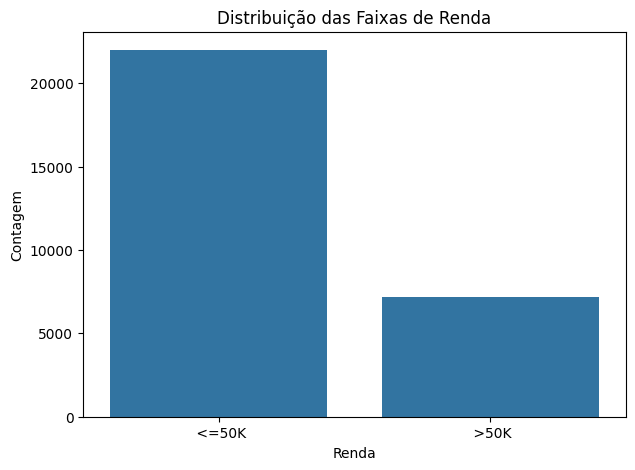

In [377]:
#Distribuição das Faixas de Renda - Variável Alvo - Visualização
plt.figure(figsize=(7, 5))
sns.countplot(x='income', data=df_mvp)
plt.title('Distribuição das Faixas de Renda')
plt.xlabel('Renda')
plt.ylabel('Contagem')
plt.show()

A variável alvo apresenta desbalanceamento considerável: a maioria dos indivíduos (75,42%) possui renda igual ou inferior a 50 mil dólares anuais, enquanto apenas 24,58% superam esse valor.

###4.3.2 Variável de interesse para o estudo (sex)

In [378]:
#Distribuição do target em tabela
contagem = df_mvp['sex'].value_counts()
proporcao = df_mvp['sex'].value_counts(normalize=True) * 100

tabela_income = pd.DataFrame({'Contagem': contagem,'Proporção (%)': proporcao.round(2)})

display(tabela_income)

,Contagem,Proporção (%)
sex,,
Male,19488,66.81
Female,9682,33.19


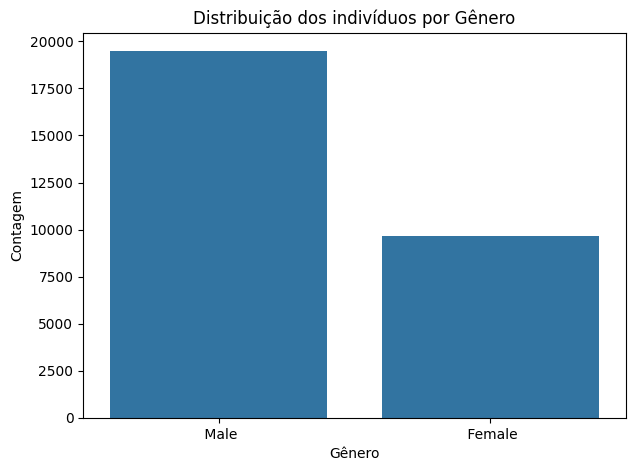

In [379]:
#Distribuição do Gênero - Visualização
plt.figure(figsize=(7, 5))
sns.countplot(x='sex', data=df_mvp)
plt.title('Distribuição dos indivíduos por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Contagem')
plt.show()

Além da análise de balanceamento da variável alvo, foi realizada uma análise da distribuição da variável sex (gênero), considerando o tema do trabalho. Existe uma maior concentração de homens, que representam 66,81% dos indivíduos.

###4.3.3 Variáveis categóricas

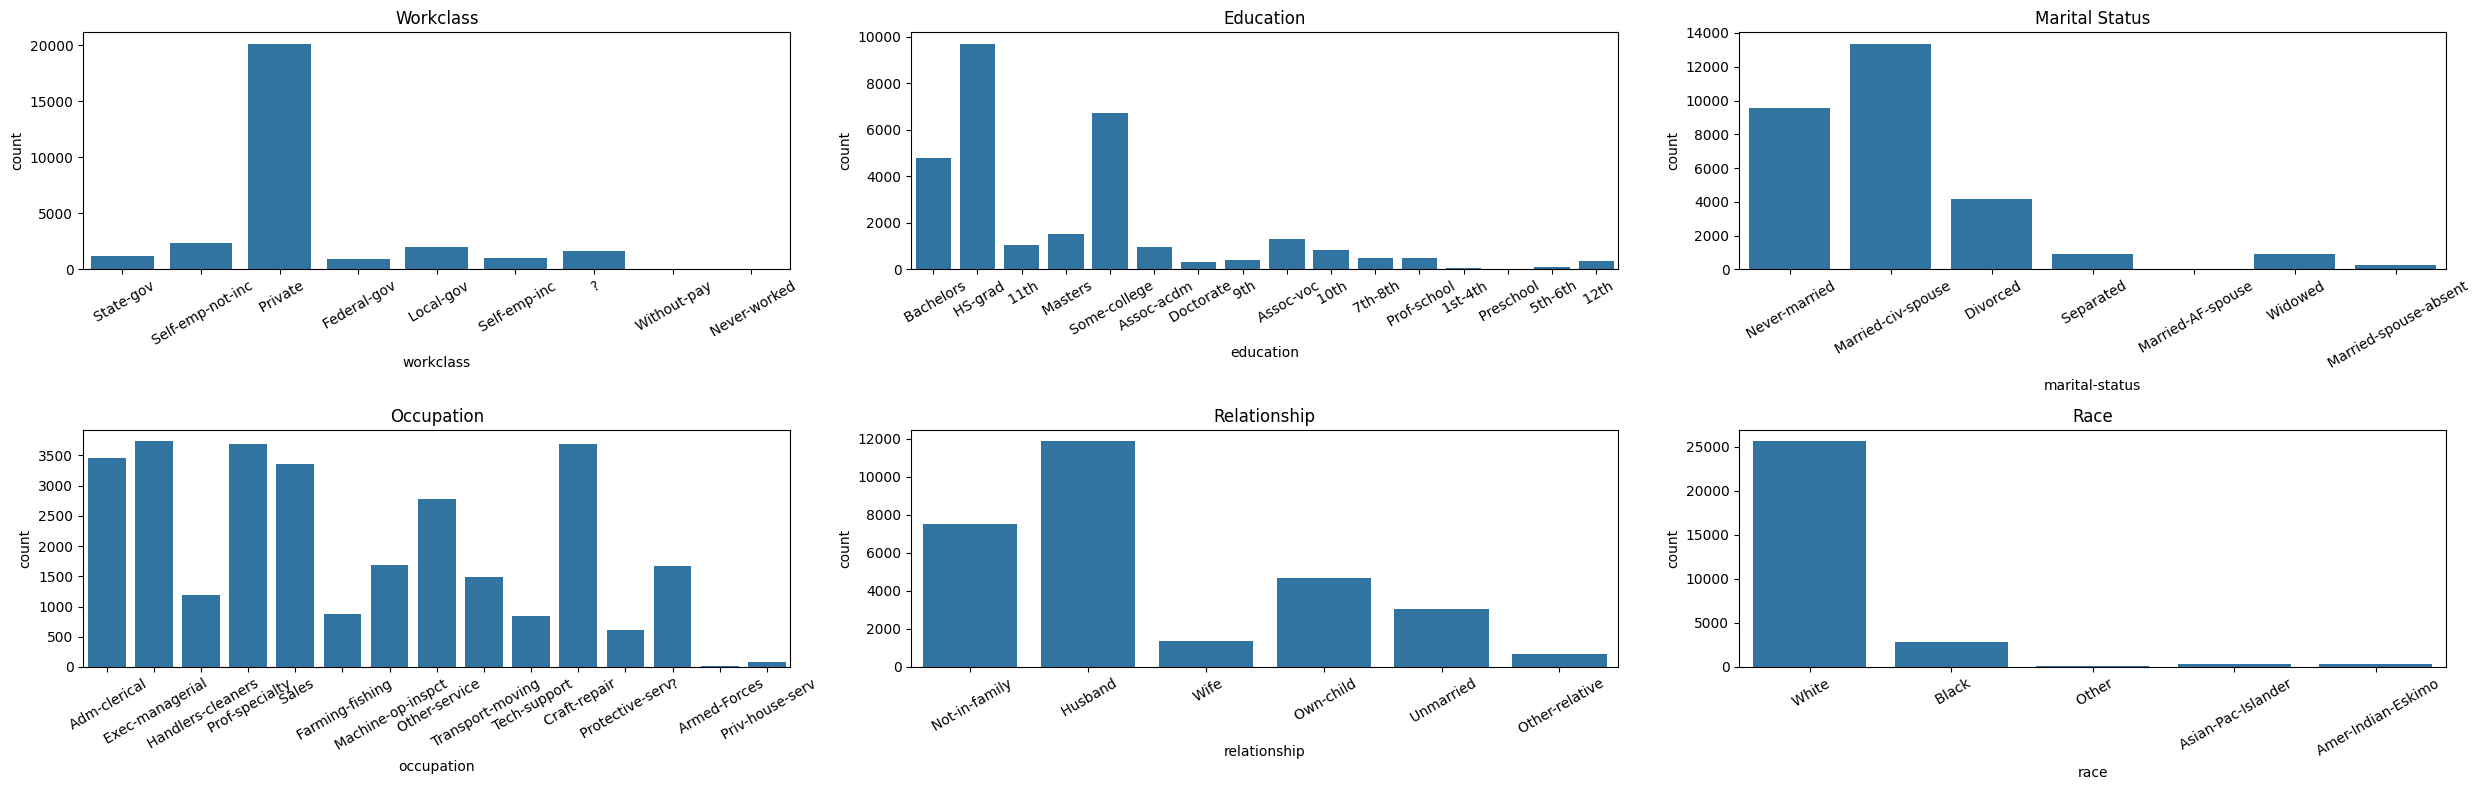

In [380]:
#Distribuição variáveis categóricas
fig, ax = plt.subplots(2, 3, figsize=(25,8))

#Workclass
sns.countplot(x='workclass', data=df_mvp, ax=ax[0,0])
ax[0,0].set_title('Workclass')
ax[0,0].tick_params(axis='x', rotation=30)

#Education
sns.countplot(x='education', data=df_mvp, ax=ax[0,1])
ax[0,1].set_title('Education')
ax[0,1].tick_params(axis='x', rotation=30)

#Marital-status
sns.countplot(x='marital-status', data=df_mvp, ax=ax[0,2])
ax[0,2].set_title('Marital Status')
ax[0,2].tick_params(axis='x', rotation=30)

#Occupation
sns.countplot(x='occupation', data=df_mvp, ax=ax[1,0])
ax[1,0].set_title('Occupation')
ax[1,0].tick_params(axis='x', rotation=30)

#Relationship
sns.countplot(x='relationship', data=df_mvp, ax=ax[1,1])
ax[1,1].set_title('Relationship')
ax[1,1].tick_params(axis='x', rotation=30)

#Race
sns.countplot(x='race', data=df_mvp, ax=ax[1,2])
ax[1,2].set_title('Race')
ax[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

As variáveis income e sex já foram avaliadas anteriormente, evidenciando desbalanceamento em suas distribuições. A variável native-country não foi considerada nesta etapa, uma vez que o dataset foi previamente filtrado para conter apenas registros dos Estados Unidos. Observa-se que as variáveis categóricas apresentam distribuições desbalanceadas, com predominância de algumas categorias, como Private em workclass, HS-grad em education, indivíduos casados em marital-status e a categoria White em race.

###4.3.4 Variáveis numéricas

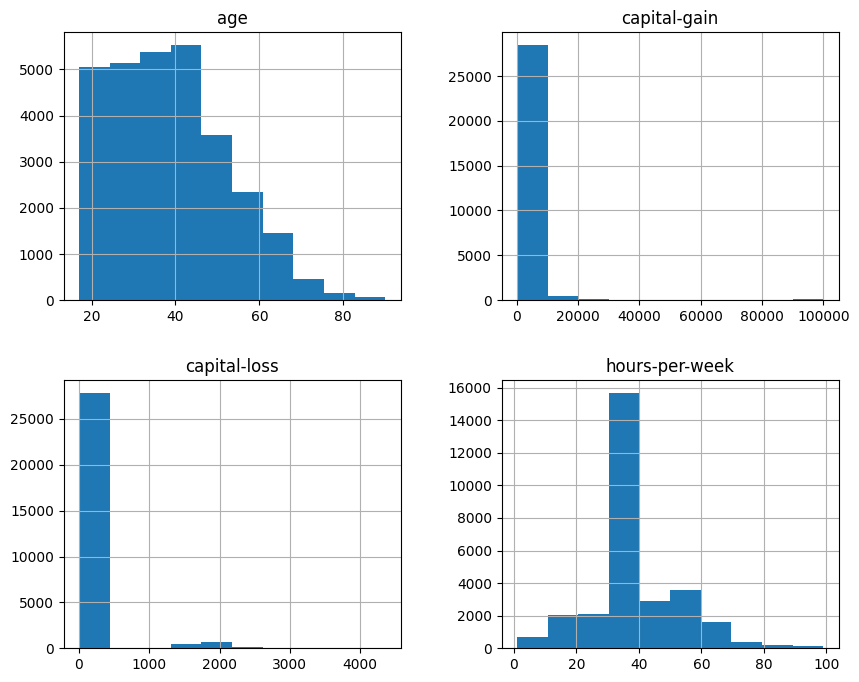

In [381]:
#Distribuição Atributos Numéricos:
df_mvp.hist(figsize=(10,8))
plt.show()

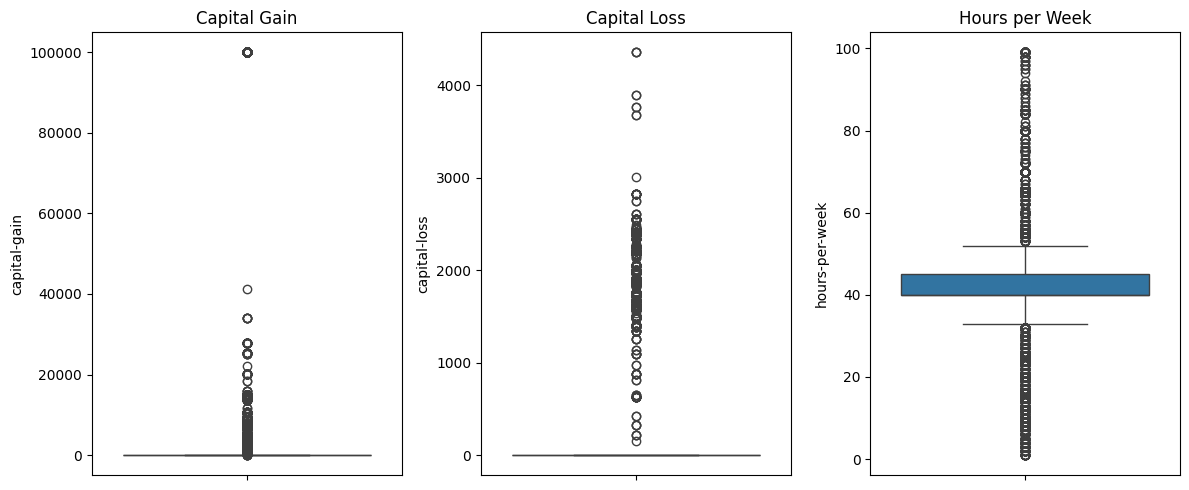

In [382]:
#Boxplot - Análise das variáveis Capital Gain, Capital Loss e Hours per Week - Outliers
fig, ax = plt.subplots(1, 3, figsize=(12,5))

#Capital Gain
sns.boxplot(y='capital-gain', data=df_mvp, ax=ax[0])
ax[0].set_title('Capital Gain')

#Capital Loss
sns.boxplot(y='capital-loss', data=df_mvp, ax=ax[1])
ax[1].set_title('Capital Loss')

#Hours per week
sns.boxplot(y='hours-per-week', data=df_mvp, ax=ax[2])
ax[2].set_title('Hours per Week')

plt.tight_layout()
plt.show()

As variáveis capital-gain e capital-loss apresentam distribuições altamente assimétricas, com grande concentração de valores em zero e poucos valores elevados. Esses valores extremos, embora possam ser considerados outliers, parecem fazer parte da natureza da variável e estão potencialmente associados a indivíduos com maior renda.
A variável hours-per-week apresenta concentração em torno de 40 horas semanais, com alguns valores mais elevados. Já a variável age apresenta uma distribuição mais equilibrada, sem grandes concentrações de valores extremos, indicando menor presença de outliers relevantes.

##4.2 Relação entre as variáveis e a variável target

###4.2.1 Variável alvo x Variável de interesse (sex)

In [383]:
#Analisando a relação da variável alvo (income) e a variável de interesse para o estudo (sex)
tabela_sexo_renda = df_mvp.groupby(['sex', 'income']).size().unstack()
tabela_sexo_renda['Total'] = tabela_sexo_renda.sum(axis=1)
tabela_sexo_renda['% >50K'] = (tabela_sexo_renda[' >50K'] / tabela_sexo_renda['Total'] * 100).round(2)
display(tabela_sexo_renda)

income,<=50K,>50K,Total,% >50K
sex,,,,
Female,8610,1072,9682,11.07
Male,13389,6099,19488,31.30


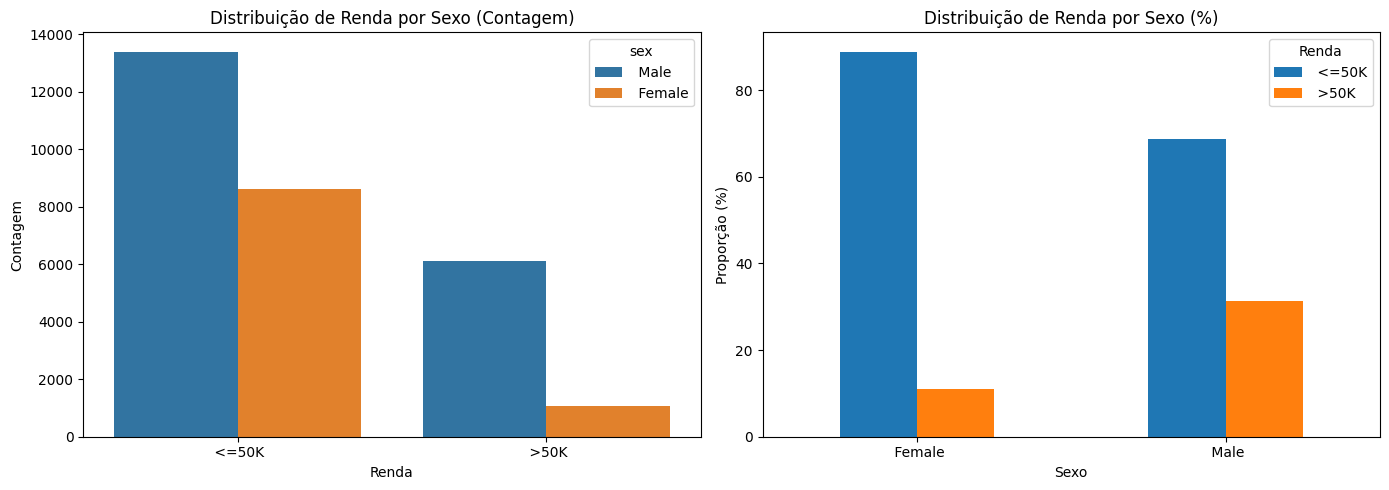

In [384]:
#Visualização da relação da variável alvo (income) e a variável de interesse para o estudo (sex)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Distruição de renda entre homens e mulheres - valor abosluto
sns.countplot(x='income', hue='sex', data=df_mvp, ax=axes[0])
axes[0].set_title('Distribuição de Renda por Sexo (Contagem)')
axes[0].set_xlabel('Renda')
axes[0].set_ylabel('Contagem')

#Distruição de renda entre homens e mulheres - valor proporcional, ajuste de escala
renda_sexo = df_mvp.groupby(['sex', 'income']).size().unstack()
renda_sexo = renda_sexo.div(renda_sexo.sum(axis=1), axis=0) * 100
renda_sexo.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('Distribuição de Renda por Sexo (%)')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Proporção (%)')
axes[1].legend(title='Renda')

plt.tight_layout()
plt.show()

Apenas 11% das mulheres ganham mais de 50 mil dólares, contra 31% dos homens. Como há muito mais homens na base, foi usado proporção, como forma adicional, para a comparação ser justa e melhor visualizada.

###4.2.2 Variável alvo x Variáveis categóricas

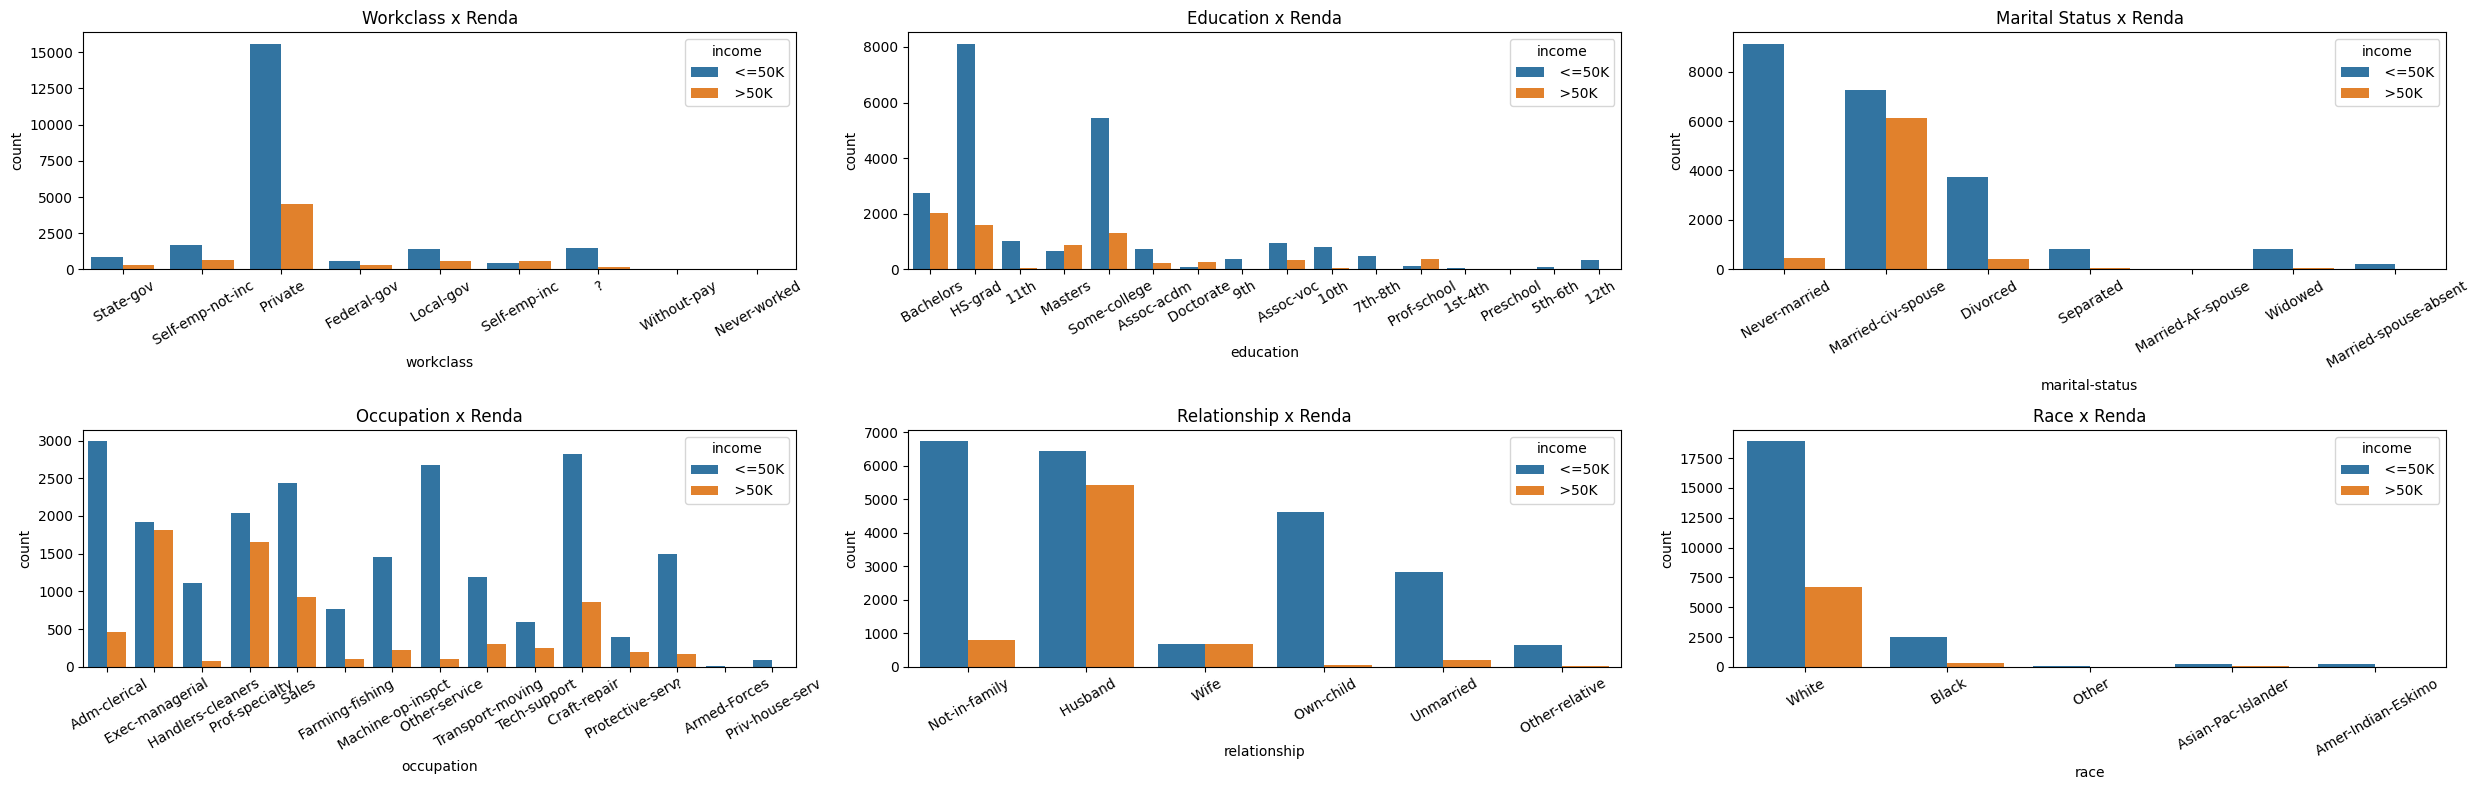

In [385]:
#Relação entre as demais variáveis categóricas e renda
fig, ax = plt.subplots(2, 3, figsize=(25,8))

#Workclass
sns.countplot(x='workclass', hue='income', data=df_mvp, ax=ax[0,0])
ax[0,0].set_title('Workclass x Renda')
ax[0,0].tick_params(axis='x', rotation=30)

#Education
sns.countplot(x='education', hue='income', data=df_mvp, ax=ax[0,1])
ax[0,1].set_title('Education x Renda')
ax[0,1].tick_params(axis='x', rotation=30)

#Marital Status
sns.countplot(x='marital-status', hue='income', data=df_mvp, ax=ax[0,2])
ax[0,2].set_title('Marital Status x Renda')
ax[0,2].tick_params(axis='x', rotation=30)

#Occupation
sns.countplot(x='occupation', hue='income', data=df_mvp, ax=ax[1,0])
ax[1,0].set_title('Occupation x Renda')
ax[1,0].tick_params(axis='x', rotation=30)

#Relationship
sns.countplot(x='relationship', hue='income', data=df_mvp, ax=ax[1,1])
ax[1,1].set_title('Relationship x Renda')
ax[1,1].tick_params(axis='x', rotation=30)

#Race
sns.countplot(x='race', hue='income', data=df_mvp, ax=ax[1,2])
ax[1,2].set_title('Race x Renda')
ax[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

Os gráficos mostram que renda mais alta está associada a maior escolaridade, ocupações gerenciais e técnicas, e ao estado civil casado. Essas variáveis serão consideradas como contexto na análise comparativa entre homens e mulheres.

###4.2.3 Variável alvo x Variáveis numéricas

In [386]:
#Matriz de correlação - Relação entre a variável alvo e as variáveis numéricas
df_corr = df_mvp.copy()
#Transformando a variável target em númerica para podermos relacionar com as outras variáveis
df_corr['income'] = df_corr['income'].map({' <=50K': 0, ' >50K': 1})
#Criando a matriz correlação
df_corr[['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']].corr()

,age,capital-gain,capital-loss,hours-per-week,income
age,1.000000,0.077409,0.057485,0.071453,0.234725
capital-gain,0.077409,1.000000,-0.032194,0.078478,0.222601
capital-loss,0.057485,-0.032194,1.000000,0.051498,0.149118
hours-per-week,0.071453,0.078478,0.051498,1.000000,0.232551
income,0.234725,0.222601,0.149118,0.232551,1.000000


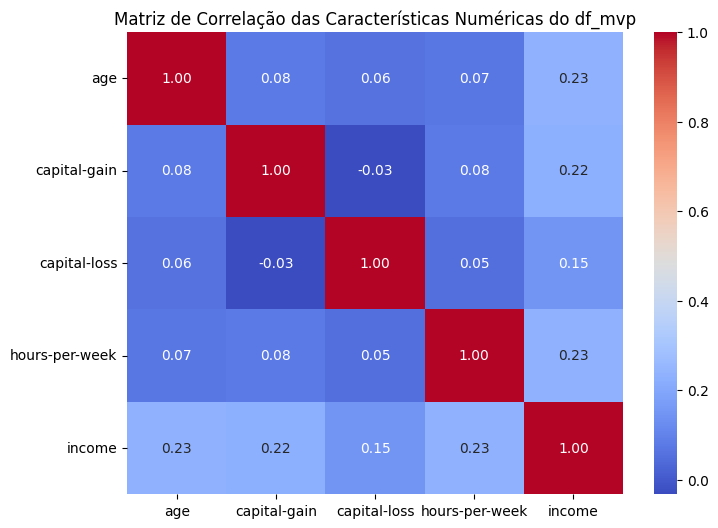

In [387]:
#Mapa de calor das variáveis numéricas:
plt.figure(figsize=(8, 6))
sns.heatmap(df_corr[['age', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Características Numéricas do df_mvp')
plt.show()

Para analisar a relação entre as variáveis numéricas e a renda, a variável alvo foi convertida para número (0 para <=50K e 1 para >50K). As variáveis apresentam baixa correlação linear com a renda, sendo age, hours-per-week e capital-gain as que mais se aproximam do target. Isso indica que a renda é influenciada pela combinação de fatores, e não por uma variável isolada.

##4.3 Respondendo as hipóteses

###4.3.1 Hipótese 1

O gênero influencia a faixa de renda do indivíduo?

In [418]:
#Criando tabelas cruzadas para entender qual a relação entre as variávies
pd.crosstab(df_mvp['sex'], df_mvp['income'], normalize='index')

income,<=50K,>50K
sex,,
Female,0.880776,0.119224
Male,0.675867,0.324133


Os resultados indicam que aproximadamente 88,5% das mulheres estão na faixa de renda de até 50K, enquanto apenas 11,5% recebem acima desse valor. Por outro lado, entre os homens, cerca de 67,8% estão na faixa de até 50K e 32,2% recebem acima de 50K.

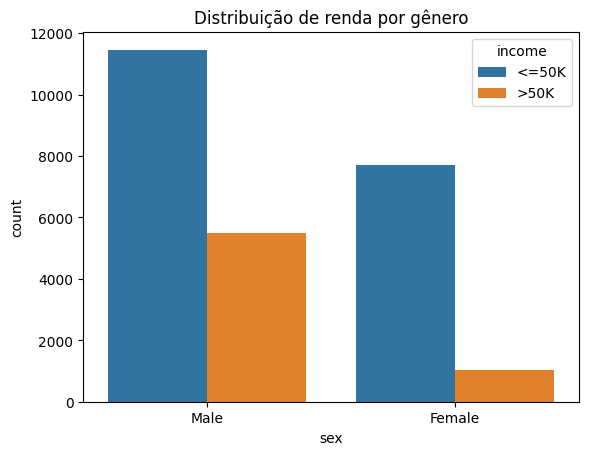

In [419]:
#Visualização Gráfica
sns.countplot(x='sex', hue='income', data=df_mvp)
plt.title('Distribuição de renda por gênero')
plt.show()

Primeiro, foi utilizado um gráfico de contagem para visualizar a distribuição das observações entre gênero e faixa de renda. No entanto, como há diferenças no número total de indivíduos em cada gênero, essa visualização pode dificultar a comparação direta das proporções. Por isso, foi criado um gráfico de barras empilhadas proporcionais, no qual cada gênero é representado na mesma escala (100%). Assim, é possível analisar de forma mais clara a distribuição relativa das faixas de renda dentro de cada grupo.

<Axes: xlabel='sex'>

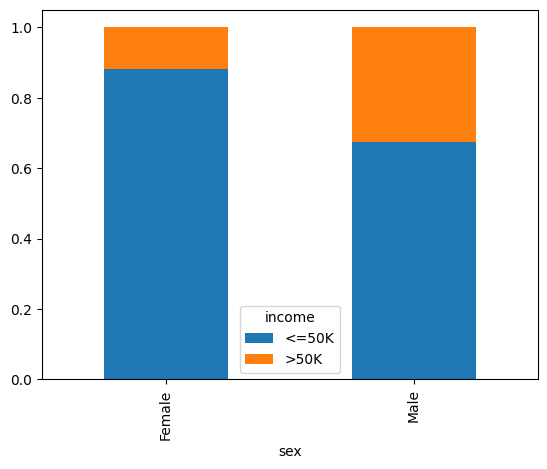

In [420]:
#Visualização Gráfica - Proporcional
prop = pd.crosstab(df_mvp['sex'], df_mvp['income'], normalize='index')
prop.plot(kind='bar', stacked=True)

De acordo com a análise de dados, a hipótese de que o gênero influencia a renda é comprovada. O gênero demonstra ser um influenciador importante na faixa de renda, com mulheres significativamente sub-representadas na categoria de renda superior.

###4.3.2 Hipótese 2
O impacto do nível educacional na faixa de renda é diferente entre homens e mulheres?

In [421]:
#Criando tabelas cruzadas para entender qual a relação entre as variávies
pd.crosstab([df_mvp['sex'], df_mvp['education']], df_mvp['income'], normalize='index')

income                  <=50K      >50K
sex    education                       
Female 10th          0.996000  0.004000
       11th          0.979827  0.020173
       12th          0.964912  0.035088
       1st-4th       1.000000  0.000000
       5th-6th       1.000000  0.000000
       7th-8th       1.000000  0.000000
       9th           0.961905  0.038095
       Assoc-acdm    0.866142  0.133858
       Assoc-voc     0.862528  0.137472
       Bachelors     0.767606  0.232394
       Doctorate     0.381579  0.618421
       HS-grad       0.931439  0.068561
       Masters       0.657620  0.342380
       Preschool     1.000000  0.000000
       Prof-school   0.531646  0.468354
       Some-college  0.920251  0.079749
Male   10th          0.896811  0.103189
       11th          0.920133  0.079867
       12th          0.896552  0.103448
       1st-4th       0.967742  0.032258
       5th-6th       0.933333  0.066667
       7th-8th       0.915531  0.084469
       9th           0.933099  0.066901
       Assoc-acdm    0.667802  0.332198
       Assoc-voc     0.665820  0.334180
       Bachelors     0.497624  0.502376
       Doctorate     0.207469  0.792531
       HS-grad       0.772701  0.227299
       Masters       0.336401  0.663599
       Preschool     1.000000  0.000000
       Prof-school   0.208232  0.791768
       Some-college  0.719410  0.280590

Para avaliar se o impacto do nível educacional na faixa de renda difere entre homens e mulheres, foi inicialmente construída uma tabela cruzada completa entre todas as categorias de escolaridade e gênero. Porém, como o nível educacional apresenta muitas classes, a tabela fica muito grande, pouco intuitiva, dificultando a visualização de padrões relevantes.
Por isso, foram selecionadas os níveis de escolaridades mais altos (Bachelors, Masters, Doctorate e Prof‑school), nas quais as diferenças salariais tendem a se tornar mais evidentes.
Assim, é possível identificar de forma mais objetiva se há disparidades de renda entre homens e mulheres dentro dos níveis educacionais mais elevados.

In [422]:
#Selecionando as categorias de ensino - Níveis de Escolaridade mais altos
df_superior = df_mvp[
    (df_mvp['education'] == 'Bachelors') |
    (df_mvp['education'] == 'Masters') |
    (df_mvp['education'] == 'Doctorate') |
    (df_mvp['education'] == 'Prof-school')]

In [423]:
#Nova tabela cruzada, considerando o nível educacional selecionado
pd.crosstab([df_superior['education'], df_superior['sex']], df_superior['income'], normalize='index')

income                 <=50K      >50K
education   sex                       
Bachelors   Female  0.767606  0.232394
            Male    0.497624  0.502376
Doctorate   Female  0.381579  0.618421
            Male    0.207469  0.792531
Masters     Female  0.657620  0.342380
            Male    0.336401  0.663599
Prof-school Female  0.531646  0.468354
            Male    0.208232  0.791768

<Axes: xlabel='education', ylabel='>50K'>

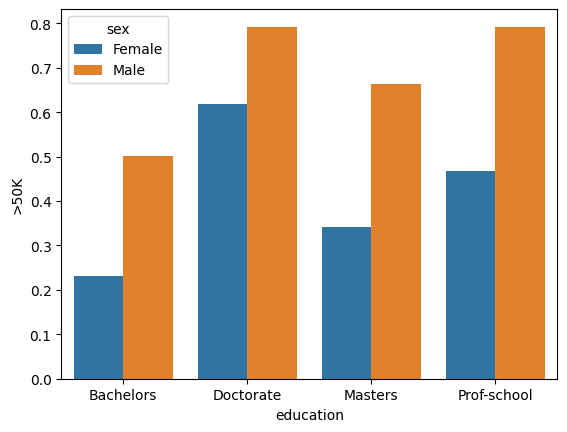

In [424]:
#Visualização gráfica, considerando a proporção dos dados - Assim é possível analisar os gêneros em mesma escala
prop = pd.crosstab([df_superior['education'], df_superior['sex']], df_superior['income'], normalize='index').reset_index()

sns.barplot(data=prop, x='education', y='>50K', hue='sex')

Os dados mostram que o nível educacional melhora a renda média de ambos o gênero, porém, não elimina a diferença salarial entre homens e mulheres. Mesmo dentro de níveis educacionais mais elevados, como Mestrado, Doutorado e Prof-school, as mulheres aparecem com maior proporção na faixa de renda mais baixa, enquanto os homens concentram maior presença na faixa >50K. Isso sugere que, embora a escolaridade avance, o retorno salarial não cresce de maneira equivalente para ambos os gêneros.

###4.3.3 Hipótese 3
A carga horária semanal de trabalho influencia de forma diferente a renda de homens e mulheres?

In [425]:
#Criação de faixas de horas de trabalho
df_mvp['hours_group'] = pd.cut(df_mvp['hours-per-week'], bins=[0, 30, 40, 50, 100], labels=['<=30', '31-40', '41-50', '>50'])

In [426]:
#Tabela cruzada - Sexo vs faixas de horas de trabalho
pd.crosstab([df_mvp['sex'], df_mvp['hours_group']],df_mvp['income'],normalize='index')

income                 <=50K      >50K
sex    hours_group                    
Female <=30         0.933454  0.066546
       31-40        0.888867  0.111133
       41-50        0.773946  0.226054
       >50          0.790000  0.210000
Male   <=30         0.916310  0.083690
       31-40        0.716305  0.283695
       41-50        0.558795  0.441205
       >50          0.545085  0.454915

De acordo com os dados, as mulheres concentram maiores proporções nas faixas de menor renda em todos os grupos de horas, enquanto homens aparecem com probabilidades superiores na renda maior, principalmente em maiores categorias de maiores cargas horárias.

<Axes: xlabel='hours_group', ylabel='>50K'>

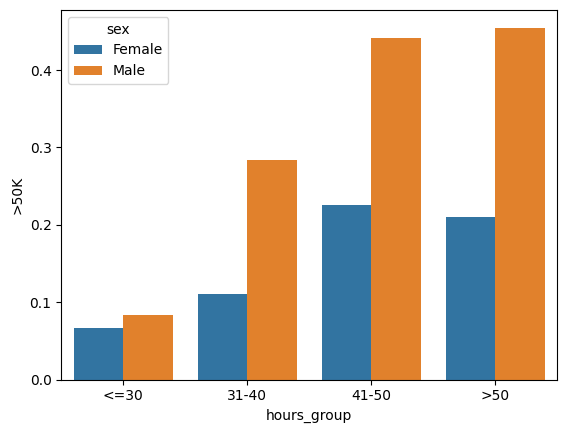

In [427]:
#Visualização gráfica, considerando a proporção dos dados - Assim é possível analisar os gêneros em mesma escala
prop = pd.crosstab([df_mvp['sex'], df_mvp['hours_group']],df_mvp['income'],normalize='index').reset_index()

sns.barplot(data=prop, x='hours_group', y='>50K', hue='sex')

Conforme a carga horária aumenta, cresce também a proporção de indivíduos que alcançam renda acima de 50K. Porém, esse crescimento é maior para homens do que para as mulheres. Em todas as faixas de horas, os homens exibem barras mais altas, indicando maior probabilidade de estarem na faixa de renda elevada. Assim, o gráfico mostra a persistência do diferencial de renda entre os gêneros.

As três hipóteses levantadas foram confirmadas pela análise exploratória. Com base nesses achados, seguimos para a etapa de pré-processamento e modelagem, com o objetivo de construir um modelo capaz de prever a faixa de renda para novos indivíduos.

#5. Preparação dos dados e divisão treino/teste




##5.1 Limpeza de Dados


In [388]:
#Ajustando escrita variáveis categóricas:
for col in df_mvp.select_dtypes(include='object'):
    df_mvp[col] = df_mvp[col].str.strip()

In [389]:
#Nova análise atributos categóricos:
for col in df_mvp.select_dtypes(include='object').columns:
    print(f"\nColuna: {col}")
    print(df_mvp[col].unique())


Coluna: workclass
['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' '?' 'Without-pay' 'Never-worked']

Coluna: education
['Bachelors' 'HS-grad' '11th' 'Masters' 'Some-college' 'Assoc-acdm'
 'Doctorate' '9th' 'Assoc-voc' '10th' '7th-8th' 'Prof-school' '1st-4th'
 'Preschool' '5th-6th' '12th']

Coluna: marital-status
['Never-married' 'Married-civ-spouse' 'Divorced' 'Separated'
 'Married-AF-spouse' 'Widowed' 'Married-spouse-absent']

Coluna: occupation
['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Sales' 'Farming-fishing' 'Machine-op-inspct' 'Other-service'
 'Transport-moving' 'Tech-support' 'Craft-repair' 'Protective-serv' '?'
 'Armed-Forces' 'Priv-house-serv']

Coluna: relationship
['Not-in-family' 'Husband' 'Wife' 'Own-child' 'Unmarried' 'Other-relative']

Coluna: race
['White' 'Black' 'Other' 'Asian-Pac-Islander' 'Amer-Indian-Eskimo']

Coluna: sex
['Male' 'Female']

Coluna: native-country
['United-States']

Coluna: income
['

##5.2 Tratamento valores duplicados, nulos e desconhecidos

In [390]:
#Remoção de duplicatas
df_mvp = df_mvp.drop_duplicates()


In [391]:
#Informações dataset mvp com a retirada desses valores
print(f"Total de instâncias: {len(df_mvp)}")
print("\nTipos de dados por coluna:")
print(df_mvp.info())

Total de instâncias: 25721

Tipos de dados por coluna:
<class 'pandas.core.frame.DataFrame'>
Index: 25721 entries, 0 to 29169
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             25721 non-null  int64 
 1   workclass       25721 non-null  object
 2   education       25721 non-null  object
 3   marital-status  25721 non-null  object
 4   occupation      25721 non-null  object
 5   relationship    25721 non-null  object
 6   race            25721 non-null  object
 7   sex             25721 non-null  object
 8   capital-gain    25721 non-null  int64 
 9   capital-loss    25721 non-null  int64 
 10  hours-per-week  25721 non-null  int64 
 11  native-country  25721 non-null  object
 12  income          25721 non-null  object
dtypes: int64(4), object(9)
memory usage: 2.7+ MB
None


Como identificado na etapa de análise exploratória, a base original possuía 29.170 registros, sendo 3.449 eram duplicatas. Optou-se pela remoção dessas linhas. Após a remoção, a base passou a contar com 25.721 registros. Em seguida, verificou-se novamente a presença de valores desconhecidos representados por ? nas colunas workclass e occupation, constatando-se que nenhum registro com esse valor permanecia na base, indicando que todas as ocorrências haviam sido eliminadas junto com as duplicatas.

In [392]:
#Número de valores '?'
(df_mvp=='?').sum()

,0
age,0
workclass,1455
education,0
marital-status,0
occupation,1462
relationship,0
race,0
sex,0
capital-gain,0
capital-loss,0


In [393]:
print(df_mvp['workclass'].value_counts())
print(df_mvp['occupation'].value_counts())

workclass
Private             17076
Self-emp-not-inc     2245
Local-gov            1903
?                    1455
State-gov            1184
Self-emp-inc          966
Federal-gov           872
Without-pay            13
Never-worked            7
Name: count, dtype: int64
occupation
Prof-specialty       3439
Exec-managerial      3389
Adm-clerical         3019
Sales                2985
Craft-repair         2886
Other-service        2480
?                    1462
Machine-op-inspct    1390
Transport-moving     1339
Handlers-cleaners    1001
Farming-fishing       848
Tech-support          796
Protective-serv       588
Priv-house-serv        90
Armed-Forces            9
Name: count, dtype: int64


In [394]:
print(df_mvp['workclass'].unique())

['State-gov' 'Self-emp-not-inc' 'Private' 'Federal-gov' 'Local-gov'
 'Self-emp-inc' '?' 'Without-pay' 'Never-worked']


In [395]:
print(df_mvp['occupation'].unique())

['Adm-clerical' 'Exec-managerial' 'Handlers-cleaners' 'Prof-specialty'
 'Sales' 'Farming-fishing' 'Machine-op-inspct' 'Other-service'
 'Transport-moving' 'Tech-support' 'Craft-repair' 'Protective-serv' '?'
 'Armed-Forces' 'Priv-house-serv']


##5.3 Divisão Treino e Teste

In [396]:
#Configuração do problema

TARGET = "income"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = []
DATE_COLUMN = None
DROP_COLUMNS = ['native-country'] #O dataset foi filtrado para conter apenas registros dos Estados Unidos, o que significa que essa coluna tem valor único para todos os registros e não agrega nenhuma informação ao modelo

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df_mvp.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df_mvp.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)


Tipo de problema: classificacao
Target: income
Número de features: 11
Features: ['age', 'workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week']


O problema foi configurado como classificação, tendo income como variável alvo. A coluna native-country foi excluída por apresentar um único valor único após o filtro aplicado ao dataset ("United States")

In [397]:
#Divisão dos dados

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df_mvp[features].copy()
    y = df_mvp[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df_mvp[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df_mvp.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df_mvp.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Treino: (20576, 11) | Teste: (5145, 11)


A divisão foi feita em 80/20, com 20.576 registros para treino e 5.145 para teste. Como o conjunto passou por etapas de limpeza, com remoção de duplicatas e registros desconhecidos, o total final foi de 25.721 instâncias, em vez dos 29.170 da base original. Ainda assim, o volume é suficiente para garantir qualidade tanto no treino quanto no teste. Como a base é desbalanceada, foi usada a estratificação na variável target para manter a proporção das classes em ambos os conjuntos. Optou-se pelo método holdout, pois o volume de dados e a estratificação já garantem uma divisão representativa.

# 6. Pré-processamento e Pipeline



##6.1 Tratamento de Outliers

Como observado na etapa de análise exploratória, as variáveis capital-gain, capital-loss e hours-per-week apresentam valores extremos que podem ser caracterizados como outliers. Dessa forma, nesta etapa será realizado o tratamento desses valores, a fim de evitar possíveis impactos negativos no desempenho dos modelos de aprendizado de máquina.

In [398]:
#Análise limites variável capital-gain
Q1_cg = X_train['capital-gain'].quantile(0.25)
Q3_cg = X_train['capital-gain'].quantile(0.75)
IQR_cg = Q3_cg - Q1_cg

limite_inferior_cg = Q1_cg - 1.5 * IQR_cg
limite_superior_cg = Q3_cg + 1.5 * IQR_cg

print(f"\nLimite Inferior: {limite_inferior_cg}")
print(f"\nLimite Superior: {limite_superior_cg}")


Limite Inferior: 0.0

Limite Superior: 0.0


In [399]:
#Análise limites variável capital-loss
Q1_cl = X_train['capital-loss'].quantile(0.25)
Q3_cl = X_train['capital-loss'].quantile(0.75)
IQR_cl = Q3_cl - Q1_cl

limite_inferior_cl = Q1_cl - 1.5 * IQR_cl
limite_superior_cl = Q3_cl + 1.5 * IQR_cl

print(f"\nLimite Inferior: {limite_inferior_cl}")
print(f"\nLimite Superior: {limite_superior_cl}")


Limite Inferior: 0.0

Limite Superior: 0.0


As variáveis "capital_gain" e "capital_loss" apresentaram alta concentração de valores iguais a zero e poucos valores elevados, caracterizando distribuição assimétrica. Esses valores representam eventos raros, porém válidos, e portanto optou-se por não aplicar tratamento de outliers, a fim de não distorcer a distribuição original dos dados.

In [400]:
#Análise limites hours-per-week
Q1_h = X_train['hours-per-week'].quantile(0.25)
Q3_h = X_train['hours-per-week'].quantile(0.75)
IQR_h = Q3_h - Q1_h

limite_inferior_h = Q1_h - 1.5 * IQR_h
limite_superior_h = Q3_h + 1.5 * IQR_h

print(f"\nLimite Inferior: {limite_inferior_h}")
print(f"\nLimite Inferior: {limite_superior_h}")


Limite Inferior: 30.0

Limite Inferior: 54.0


In [401]:
#Aplicar limites no treino
X_train['hours-per-week'] = np.where(
    X_train['hours-per-week'] < limite_inferior_h,
    limite_inferior_h,
    X_train['hours-per-week'])

X_train['hours-per-week'] = np.where(
    X_train['hours-per-week'] > limite_superior_h,
    limite_superior_h,
    X_train['hours-per-week'])

In [402]:
#Aplicar limites no treino
X_test['hours-per-week'] = np.where(
    X_test['hours-per-week'] < limite_inferior_h,
    limite_inferior_h,
    X_test['hours-per-week'])

X_test['hours-per-week'] = np.where(
    X_test['hours-per-week'] > limite_superior_h,
    limite_superior_h,
    X_test['hours-per-week'])

In [403]:
#Chegando a aplicação dos limites
print(X_train['hours-per-week'].min())
print(X_train['hours-per-week'].max())

30.0
54.0



A variável "hours-per-week" apresentou valores extremos que podem indicar comportamentos atípicos. Para o tratamento de outliers, foi aplicada a técnica de IQR (Intervalo Interquartil), com abordagem de capping, na qual os valores foram limitados com base nos limites inferior e superior definidos a partir dos quartis.

##6.2 Pipeline

In [404]:
#Identificação de colunas
num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=np.number).columns.tolist()

if DATE_COLUMN in cat_cols:
    cat_cols.remove(DATE_COLUMN)
if DATE_COLUMN in num_cols:
    num_cols.remove(DATE_COLUMN)

#Pipeline numérico
numeric_pipe = Pipeline(steps=[
    ("scaler", StandardScaler())
])

#Pipeline categórico
categorical_pipe = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

#SMOTE para balanceamento (só no treino)
X_train_proc = preprocess.fit_transform(X_train)
X_test_proc = preprocess.transform(X_test)

X_train_bal, y_train_bal = SMOTE(random_state=SEED).fit_resample(X_train_proc, y_train)

print("Colunas numéricas:", num_cols)
print("Colunas categóricas:", cat_cols)
print("Shape treino balanceado:", X_train_bal.shape)

Colunas numéricas: ['age', 'capital-gain', 'capital-loss', 'hours-per-week']
Colunas categóricas: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex']
Shape treino balanceado: (30686, 64)


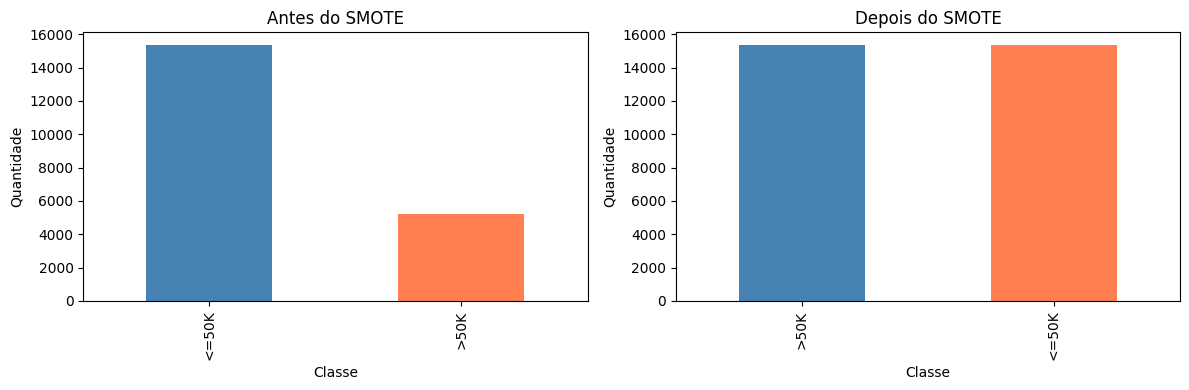

In [405]:
#Comparação antes x depois do SMOTE
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

#Antes
pd.Series(y_train).value_counts().plot(kind='bar', ax=ax[0], color=['steelblue', 'coral'])
ax[0].set_title('Antes do SMOTE')
ax[0].set_xlabel('Classe')
ax[0].set_ylabel('Quantidade')

#Depois
pd.Series(y_train_bal).value_counts().plot(kind='bar', ax=ax[1], color=['steelblue', 'coral'])
ax[1].set_title('Depois do SMOTE')
ax[1].set_xlabel('Classe')
ax[1].set_ylabel('Quantidade')

plt.tight_layout()
plt.show()

As variáveis categóricas foram transformadas em variáveis numéricas por meio da técnica de one-hot encoding, e as variáveis numéricas foram padronizadas com o StandardScaler. Essas transformações foram organizadas em um pipeline de pré-processamento, composto por dois sub-pipelines: um para variáveis numéricas, com padronização, e outro para variáveis categóricas, com aplicação do one-hot encoding. Essa abordagem garante que o ajuste das transformações ocorra apenas nos dados de treino, sendo posteriormente aplicado ao conjunto de teste, evitando vazamento de informação (data leakage).
Como identificado na etapa de análise exploratória, a variável alvo income apresenta desbalanceamento, com predominância de indivíduos na faixa de renda menor ou igual a 50k. Dessa forma, após a aplicação do pipeline de pré-processamento, foi aplicada a técnica SMOTE exclusivamente no conjunto de treino, com o objetivo de equilibrar as classes por meio da geração de exemplos sintéticos da classe minoritária. Após essa etapa, a base de treino passou a apresentar a mesma quantidade de registros para ambas as classes, favorecendo um aprendizado mais equilibrado do modelo.

# 7. Baseline e modelos candidatos


In [406]:
#Definição de baseline e modelos candidatos
if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("model", RandomForestClassifier(random_state=SEED))
        ]),
        "GradientBoosting": Pipeline(steps=[
            ("model", GradientBoostingClassifier(random_state=SEED))
        ]),
        "KNN": Pipeline(steps=[
            ("model", KNeighborsClassifier())
        ])
    }

print("Modelos candidatos:", list(candidates.keys()))

Modelos candidatos: ['LogisticRegression', 'RandomForest', 'GradientBoosting', 'KNN']


Para a construção e avaliação do modelo de classificação de renda, foram utilizados diferentes algoritmos, com o objetivo de comparar abordagens distintas e identificar qual melhor se ajusta ao problema.
Inicialmente, foi definido um modelo baseline a partir do DummyClassifier, utilizando a estratégia most_frequent, que consiste em sempre prever a classe majoritária (≤50K). Esse modelo serve como referência mínima de desempenho: qualquer modelo que não supere seus resultados não está capturando padrões relevantes nos dados, indicando ausência de aprendizado efetivo.

Como primeiro modelo, foi aplicada a Regressão Logística, que representa uma abordagem linear simples, interpretável e computacionalmente eficiente. Esse modelo é sensível à escala das variáveis, sendo diretamente beneficiado pela padronização aplicada no pipeline. Sua utilização permite avaliar se a relação entre as variáveis explicativas e a variável alvo pode ser adequadamente representada de forma linear.

Na sequência, foi utilizado o Random Forest, um modelo baseado em árvores de decisão que utiliza a técnica de bagging para formar um ensemble. Esse algoritmo é capaz de capturar relações não-lineares, lidar com variáveis em diferentes escalas e apresenta boa robustez a outliers, sendo adequado para dados tabulares mais complexos.

Complementando essa abordagem, foi aplicado o Gradient Boosting, também baseado em árvores, porém utilizando a técnica de boosting, onde os modelos são construídos sequencialmente com o objetivo de corrigir erros das iterações anteriores. Esse tipo de modelo tende a apresentar alto desempenho em problemas de dados tabulares, sendo uma escolha relevante para comparação com o Random Forest.

Por fim, foi incluído o modelo K-Nearest Neighbors (KNN), que se baseia na similaridade entre observações, classificando novos dados a partir dos seus vizinhos mais próximos. Esse modelo não assume uma forma funcional específica para os dados, representando uma abordagem distinta das anteriores. Assim como a Regressão Logística, o KNN é sensível à escala das variáveis, sendo favorecido pela padronização aplicada no pré-processamento.

# 8. Treinamento e avaliação inicial



In [407]:
#Baseline
t0 = time.time()
baseline.fit(X_train_bal, y_train_bal)
train_time = time.time() - t0
y_pred = baseline.predict(X_test_proc)
proba = baseline.predict_proba(X_test_proc) if hasattr(baseline, "predict_proba") else None
results["baseline"] = evaluate_classification(y_test, y_pred, proba)
results["baseline"]["train_time_s"] = round(train_time, 3)
trained_models["baseline"] = baseline

#Modelos candidatos
for name, model in candidates.items():
    t0 = time.time()
    model.fit(X_train_bal, y_train_bal)
    train_time = time.time() - t0
    y_pred = model.predict(X_test_proc)
    proba = model.predict_proba(X_test_proc) if hasattr(model, "predict_proba") else None
    results[name] = evaluate_classification(y_test, y_pred, proba)
    results[name]["train_time_s"] = round(train_time, 3)
    trained_models[name] = model

show_results_table(results)

,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.745773,0.63717,0.5,0.054
GradientBoosting_otimizado,0.857532,0.860477,0.927426,-
LogisticRegression,0.81516,0.824111,0.911084,1.174
RandomForest,0.823518,0.822976,0.8798,5.362
GradientBoosting,0.831098,0.837618,0.91976,8.625
KNN,0.780758,0.791217,0.842665,0.05


Os resultados iniciais mostram que todos os modelos candidatos superaram o baseline (F1 = 0.637) em mais de 10 pontos percentuais, atingindo o critério de sucesso definido. O Gradient Boosting obteve o melhor desempenho geral (F1 = 0.838, ROC-AUC = 0.920), seguido de perto pela Regressão Logística e Random Forest, que apresentaram resultados similares. O KNN foi o modelo com menor desempenho, sugerindo que a abordagem baseada em distância é menos adequada para este problema. O tempo de treinamento de todos os modelos foi aceitável, variando de 0.03s a 8.5s. Os resultados são coerentes com a EDA, que indicou que nenhuma variável isolada explica bem a renda, favorecendo modelos que capturam interações entre variáveis. Com base nisso, o Gradient Boosting será selecionado para a etapa de otimização de hiperparâmetros.

# 9. Validação e otimização de hiperparâmetros



In [408]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.
N_ITER_SEARCH = 5

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    model_to_tune = Pipeline(steps=[
        ("model", GradientBoostingClassifier(random_state=SEED))
    ])

    param_dist = {
        "model__n_estimators": randint(50, 150),
        "model__max_depth": randint(2, 8),
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__min_samples_split": randint(2, 10)
    }

    scoring = "f1_weighted"

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,
        verbose=1
    )
    search.fit(X_train_bal, y_train_bal)

    print("Melhor score na validação:", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Melhor score na validação: 0.8886736324947182
Melhores hiperparâmetros: {'model__learning_rate': 0.1, 'model__max_depth': 6, 'model__min_samples_split': 6, 'model__n_estimators': 132}


O Gradient Boosting foi otimizado com RandomizedSearchCV, 3 folds e 5 iterações, guiado pelo F1-score. A melhor configuração encontrada foi learning_rate=0.1, max_depth=6, min_samples_split=6 e n_estimators=132, obtendo F1 = 0.889 na validação.

In [409]:
#Validação do Teste
best_model = search.best_estimator_
y_pred = best_model.predict(X_test_proc)
proba = best_model.predict_proba(X_test_proc)
results["GradientBoosting_otimizado"] = evaluate_classification(y_test, y_pred, proba)
results["GradientBoosting_otimizado"]["train_time_s"] = "-"
show_results_table(results)

,accuracy,f1_weighted,roc_auc,train_time_s
baseline,0.745773,0.63717,0.5,0.054
GradientBoosting_otimizado,0.857532,0.860477,0.927426,-
LogisticRegression,0.81516,0.824111,0.911084,1.174
RandomForest,0.823518,0.822976,0.8798,5.362
GradientBoosting,0.831098,0.837618,0.91976,8.625
KNN,0.780758,0.791217,0.842665,0.05


O modelo otimizado obteve o melhor desempenho geral (F1 = 0.860, ROC-AUC = 0.927), superando todos os candidatos e o baseline. A otimização trouxe um ganho de aproximadamente 2 pontos percentuais em relação ao Gradient Boosting sem otimização. A busca foi limitada a 5 iterações e 3 folds por custo computacional, o que restringe o espaço explorado. Com mais tempo, seria interessante aumentar o número de iterações e testar outros hiperparâmetros, como subsample e min_samples_leaf.

# 10. Avaliação final no conjunto de teste


Modelo final: GradientBoosting_otimizado
              precision    recall  f1-score   support

       <=50K       0.92      0.88      0.90      3837
        >50K       0.69      0.79      0.74      1308

    accuracy                           0.86      5145
   macro avg       0.81      0.84      0.82      5145
weighted avg       0.87      0.86      0.86      5145



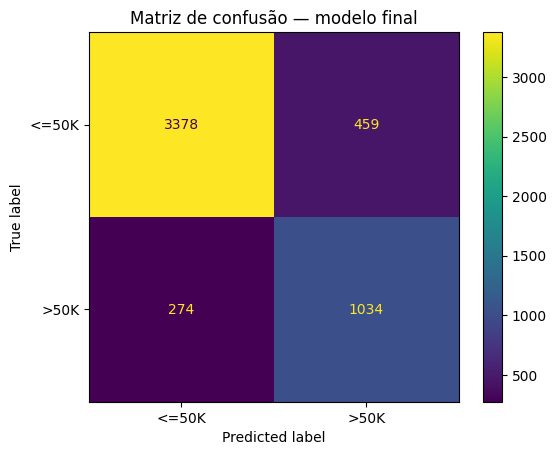

In [410]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "GradientBoosting_otimizado"

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test_proc)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test_proc, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

O modelo final (Gradient Boosting otimizado) atingiu acurácia de 0,86 e F1 ponderado de 0,86 no conjunto de teste. O principal erro do modelo está na classe minoritária (>50K), com 274 falsos negativos, ou seja, indivíduos com renda mais alta sendo classificados incorretamente como ≤50K. Esse comportamento se reflete no F1 menor para essa classe (0,74 em comparação com 0,90).
Não há evidências de overfitting, já que o desempenho no conjunto de teste é consistente com os resultados obtidos na validação cruzada. Por fim, é importante destacar que o modelo possui limitação de generalização, pois foi treinado com dados do Census dos Estados Unidos, podendo não apresentar o mesmo desempenho em populações com características diferentes.

# 11. Comparação final dos modelos

| Modelo | Métrica principal | Outras métricas | Tempo de treino | Observações |
|---|---:|---:|---:|---|
| Baseline | F1 = 0.637 | Acurácia = 0.746, ROC-AUC = 0.500 | 0.03s | Sempre prevê <=50K |
| Regressão Logística | F1 = 0.824 | Acurácia = 0.815, ROC-AUC = 0.911 | 0.65s | Bom desempenho com baixo custo |
| Random Forest | F1 = 0.823 | Acurácia = 0.824, ROC-AUC = 0.880 | 5.0s | Resultado similar à Regressão Logística |
| GradientBoosting | F1 = 0.838 | Acurácia = 0.831, ROC-AUC = 0.920 | 8.1s | Melhor candidato sem otimização |
| KNN | F1 = 0.791 | Acurácia = 0.781, ROC-AUC = 0.843 | 0.05s | Pior desempenho entre os candidatos |
| Modelo otimizado | F1 = 0.860 | Acurácia = 0.858, ROC-AUC = 0.927 | - | Melhor modelo geral |


# 12. Boas práticas e rastreabilidade


| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Seed = 42 | Garantir reprodutibilidade | Resultados consistentes em todas as execuções |
| Remover duplicatas | Não agregam informação | Evitar viés na frequência de padrões |
| Remover registros com `?` | Apenas ~5% da base | Evitar ruído sem perda significativa de dados |
| Remover `native-country` | Apenas registros dos EUA | Evitar coluna com valor único |
| Pipeline com StandardScaler e OneHotEncoder | Padronização e encoding sem leakage | Transformações aplicadas corretamente no treino e teste |
| Usar SMOTE | Desbalanceamento 75/25 | Melhorar aprendizado da classe minoritária |
| Usar F1-score como métrica | Classes desbalanceadas | Avaliar melhor a classe minoritária |
| Selecionar Gradient Boosting | Melhor F1 e ROC-AUC entre os candidatos | Melhor generalização no teste |
| Limitar busca a 5 iterações | Custo computacional | Reduzir tempo mantendo resultado aceitável |
| Descartar imputação | Ausentes representavam ~5% da base | Simplicidade sem perda significativa |


# 13. Conclusão

Este trabalho teve como objetivo classificar indivíduos de acordo com sua faixa de renda (≤50K ou >50K) a partir de características demográficas e profissionais dos indivíduos, com foco especial na comparação entre homens e mulheres.

O melhor modelo encontrado foi o Gradient Boosting otimizado, com F1 = 0.860 e ROC-AUC = 0.927, superando o baseline (F1 = 0.637) em mais de 22 pontos percentuais, acima do critério de sucesso definido de 10 pontos percentuais. Todos os modelos candidatos superaram o baseline, confirmando que as características demográficas e profissionais disponíveis no dataset são informativas para a previsão de renda.

Os principais aprendizados foram que nenhuma variável isolada explica bem a renda e que modelos baseados em ensemble se mostraram mais adequados para capturar essas relações complexas. As principais limitações são a restrição geográfica do dataset (apenas EUA) e a busca de hiperparâmetros limitada por custo computacional. Como próximos passos, seria interessante aprofundar a análise de importância de features separadamente por gênero

A análise das hipóteses evidenciou que as mulheres apresentam probabilidades menores de alcançar a faixa de renda superior a 50K. Em todas as hipóteses testadas, o impacto das horas trabalhadas, a influência do nível educacional e a interação entre esses fatores com o gênero, os resultados convergiram para o mesmo ponto: o gênero permanece como uma variável determinante para a renda, ainda que não devesse ser. Trabalhar mais não gera para as mulheres o mesmo retorno que para os homens, e mesmo entre indivíduos com mestrado, doutorado e formação profissional avançada, as mulheres continuaram recebendo proporcionalmente menos. Ou seja, a qualificação feminina não é traduzida em equidade salarial, indicando que o problema não está na formação, mas na forma como o mercado remunera pessoas de gêneros diferentes por competências semelhantes.

A desigualdade de gênero no mercado de trabalho não é fruto de diferenças individuais, mas de estruturas sistêmicas que limitam o retorno financeiro das mulheres, mesmo quando apresentam igual ou maior qualificação. Superar essas desigualdades exige mais do que políticas pontuais: exige transformação cultural, institucional e organizacional, além de um esforço contínuo para eliminar vieses que ainda hoje moldam a trajetória profissional das mulheres.